# ATLAS VAE Demo
### Animal Trajectory Latent Alignment Space

This notebook demonstrates the full ATLAS cross-species VAE pipeline using **synthetic data** that mirrors the real jellyfish / stickleback experiment.

| | Jellyfish (synthetic) | Fish (synthetic) |
|---|---|---|
| Window | 60 s at 1 FPS | 5 s at 1 FPS |
| Signal | hull-area rate of change | centroid speed |
| Temperature | continuous ramp (4 experiment types) | two fixed groups (17 °C / 22.5 °C) |

The model (`BehavioralVAE`) and training utilities are imported from the `atlas` library (`src/atlas/`).

## Step 1 — Imports & constants

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

from atlas.model import BehavioralVAE
from atlas.train import train, encode_all

torch.manual_seed(42)
np.random.seed(42)

# ── Species window parameters ──────────────────────────────────────────────────
JELLY_WINDOW = 60   # seconds (= samples at 1 FPS)
FISH_WINDOW  = 5
LATENT_DIM   = 8
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: cpu


## Step 2 — Synthetic behavioural data

We generate speed/activity windows for each species.  The signal for each window is:

```
activity(t) = baseline + temperature_effect * sin(2π t / period) + noise
```

- **Jellyfish**: 4 experiment types with different temperature profiles (heating crash, cooling crash, sub-threshold, cook).  Activity rises with temperature until a crash threshold.
- **Fish**: two groups at 17 °C and 22.5 °C.  Higher temperature → higher wiggle speed.

This mimics the real data structure without requiring the actual `.mat` / `.h5` files.

In [2]:
# ── Jellyfish synthetic windows ───────────────────────────────────────────────
np.random.seed(0)

EXPERIMENTS = [
    {"label": "36°C sub-crash (heating)",  "temp_range": (20, 34), "crash": False, "n": 120},
    {"label": "40°C crash (heating)",      "temp_range": (20, 38), "crash": True,  "n": 120},
    {"label": "0°C crash (cooling)",       "temp_range": (20,  4), "crash": True,  "n": 120},
    {"label": "50°C cook (heating)",       "temp_range": (20, 36), "crash": True,  "n": 120},
]

def make_jelly_windows(exp, n_windows=120, window=60, noise=0.3):
    """Simulate jellyfish activity windows for one experiment."""
    t_lo, t_hi = exp["temp_range"]
    windows, temps = [], []
    for i in range(n_windows):
        # Assign a random temperature within the ramp
        temp = np.random.uniform(min(t_lo, t_hi), max(t_lo, t_hi))
        # Activity peaks at intermediate temperature; crashes at extremes
        dist_from_20 = abs(temp - 20)
        if exp["crash"] and dist_from_20 > 14:
            activity_level = max(0.1, 1.0 - (dist_from_20 - 14) / 6)
        elif not exp["crash"]:
            activity_level = 0.5 + 0.6 * (dist_from_20 / 14)   # sub-crash: stays elevated
        else:
            activity_level = 0.4 + 0.6 * min(dist_from_20 / 14, 1.0)
        # Generate window: slow oscillation + noise
        t_arr = np.linspace(0, 1, window)
        sig = activity_level * (1 + 0.3 * np.sin(2 * np.pi * 2 * t_arr))
        sig += np.random.normal(0, noise, window)
        windows.append(sig)
        temps.append(temp)
    return np.array(windows), np.array(temps)

jelly_windows_list, jelly_temps_list, jelly_labels_list = [], [], []
for exp in EXPERIMENTS:
    w, t = make_jelly_windows(exp, n_windows=exp["n"])
    jelly_windows_list.append(w)
    jelly_temps_list.append(t)
    jelly_labels_list.append(np.full(len(w), exp["label"]))

jelly_windows = np.vstack(jelly_windows_list)   # (N_j, 60)
jelly_temps   = np.concatenate(jelly_temps_list)
jelly_labels  = np.concatenate(jelly_labels_list)

# ── Fish synthetic windows ─────────────────────────────────────────────────────
def make_fish_windows(temp_c, n_windows=200, window=5, noise=0.4):
    """Simulate fish centroid-speed windows at a fixed temperature."""
    # Higher temperature → more vigorous wiggling
    activity_level = 0.3 + 0.6 * (temp_c - 15) / 10
    windows, temps = [], []
    for _ in range(n_windows):
        sig = activity_level * np.ones(window)
        sig += np.random.normal(0, noise, window)
        sig = np.abs(sig)   # speed is non-negative
        windows.append(sig)
        temps.append(temp_c)
    return np.array(windows), np.array(temps)

fw_17,  ft_17  = make_fish_windows(17.0,  n_windows=200)
fw_225, ft_225 = make_fish_windows(22.5,  n_windows=200)
fish_windows = np.vstack([fw_17, fw_225])   # (N_f, 5)
fish_temps   = np.concatenate([ft_17, ft_225])

print(f"Jellyfish windows: {jelly_windows.shape}  |  temp range: {jelly_temps.min():.1f}–{jelly_temps.max():.1f} °C")
print(f"Fish windows:      {fish_windows.shape}   |  temps: {np.unique(fish_temps)}")

Jellyfish windows: (480, 60)  |  temp range: 4.0–37.6 °C
Fish windows:      (400, 5)   |  temps: [17.  22.5]


## Step 3 — Per-species z-scoring

Speed and hull-area-change are not in the same units.  We z-score each species independently so both encoders receive unit-variance inputs.  Temperature labels are also z-scored per species.

In [3]:
# ── Per-species z-score of activity windows ───────────────────────────────────
j_speed_mean = np.nanmean(jelly_windows);  j_speed_std = np.nanstd(jelly_windows)
f_speed_mean = np.nanmean(fish_windows);   f_speed_std = np.nanstd(fish_windows)

jelly_z = ((jelly_windows - j_speed_mean) / j_speed_std)[:, :, np.newaxis]  # (N_j, 60, 1)
fish_z  = ((fish_windows  - f_speed_mean) / f_speed_std)[:,  :, np.newaxis]  # (N_f,  5, 1)

jelly_z = np.nan_to_num(jelly_z, nan=0.0)
fish_z  = np.nan_to_num(fish_z,  nan=0.0)

# ── Per-species z-score of temperature labels ──────────────────────────────────
j_temp_mean = np.mean(jelly_temps);  j_temp_std = np.std(jelly_temps)
f_temp_mean = np.mean(fish_temps);   f_temp_std = np.std(fish_temps)

jelly_temps_z = (jelly_temps - j_temp_mean) / j_temp_std
fish_temps_z  = (fish_temps  - f_temp_mean) / f_temp_std

print(f"Jellyfish: {len(jelly_z):4d} windows  |  speed mean={j_speed_mean:.3f}  std={j_speed_std:.3f}")
print(f"Fish:      {len(fish_z):4d} windows  |  speed mean={f_speed_mean:.3f}  std={f_speed_std:.3f}")

Jellyfish:  480 windows  |  speed mean=0.739  std=0.382
Fish:       400 windows  |  speed mean=0.620  std=0.391


## Step 4 — Model

`BehavioralVAE` is imported from `atlas.model`.  Species-specific Conv1d encoders feed into a shared 8-D latent space; a shared `TempHead` regresses normalised temperature from z.

See [docs/model_architecture.md](../docs/model_architecture.md) for a full description.

In [4]:
model = BehavioralVAE(latent_dim=LATENT_DIM,
                      jelly_seq=JELLY_WINDOW,
                      fish_seq=FISH_WINDOW)

BETA        = 4.0
LAMBDA_TEMP = 2.0
print(f"BehavioralVAE — jelly_window={JELLY_WINDOW}s, fish_window={FISH_WINDOW}s, "
      f"latent_dim={LATENT_DIM}, β={BETA}, λ_temp={LAMBDA_TEMP}")
print(model)

BehavioralVAE — jelly_window=60s, fish_window=5s, latent_dim=8, β=4.0, λ_temp=2.0
BehavioralVAE(
  (jelly_enc): SpeciesEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): ReLU()
      (8): AdaptiveAvgPool1d(output_size=4)
    )
    (fc): Sequential(
      (0): Linear(in_features=512, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=16, bias=True)
    )
  )
  (fish_enc): SpeciesEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stri

## Step 5 — Training

`atlas.train.train()` handles the interleaved jellyfish / fish mini-batches, KL annealing, and the combined ELBO + temperature regression loss.

Training on synthetic data is fast — 80 epochs is enough to demonstrate convergence.

In [5]:
history = train(
    model,
    jelly_z, jelly_temps_z,
    fish_z,  fish_temps_z,
    n_epochs=80,
    n_anneal=20,
    beta=BETA,
    lambda_temp=LAMBDA_TEMP,
    batch=64,
    lr=1e-3,
    log_every=10,
    device=DEVICE,
)

Epoch   1/80  β=0.20  loss=6.1985  recon=2.0289  KL=0.0229  temp=2.0825
Epoch  10/80  β=2.00  loss=5.2947  recon=1.5414  KL=0.2028  temp=1.6739
Epoch  20/80  β=4.00  loss=5.3697  recon=1.6294  KL=0.1195  temp=1.6311
Epoch  30/80  β=4.00  loss=4.9438  recon=1.6093  KL=0.1608  temp=1.3456
Epoch  40/80  β=4.00  loss=4.2500  recon=1.6238  KL=0.2130  temp=0.8870
Epoch  50/80  β=4.00  loss=3.8253  recon=1.6327  KL=0.2398  temp=0.6167
Epoch  60/80  β=4.00  loss=3.5530  recon=1.5977  KL=0.2703  temp=0.4370
Epoch  70/80  β=4.00  loss=3.3631  recon=1.6122  KL=0.2555  temp=0.3645
Epoch  80/80  β=4.00  loss=3.3281  recon=1.5799  KL=0.2830  temp=0.3080

Training complete.


## Step 6 — Training diagnostics

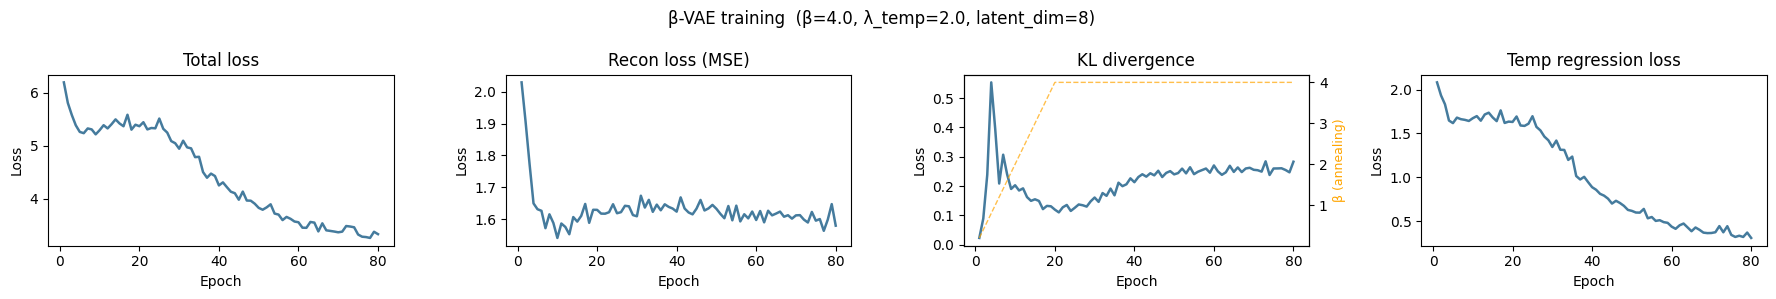

In [6]:
hist = np.array(history)   # cols: epoch, beta, total, recon, kl, temp

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
specs = [(2, 'Total loss'), (3, 'Recon loss (MSE)'),
         (4, 'KL divergence'), (5, 'Temp regression loss')]

for ax, (col, lbl) in zip(axes, specs):
    ax.plot(hist[:, 0], hist[:, col], lw=1.8, color='#457b9d')
    if lbl == 'KL divergence':
        ax2 = ax.twinx()
        ax2.plot(hist[:, 0], hist[:, 1], lw=1, color='orange',
                 linestyle='--', alpha=0.7)
        ax2.set_ylabel('β (annealing)', color='orange', fontsize=9)
    ax.set_title(lbl); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

plt.suptitle(f'β-VAE training  (β={BETA}, λ_temp={LAMBDA_TEMP}, latent_dim={LATENT_DIM})',
             fontsize=12)
plt.tight_layout()
plt.show()

## Step 7 — Shared latent space (UMAP)

We encode all windows to their posterior means μ, concatenate jellyfish and fish, and fit a single UMAP embedding. Five panels test cross-species alignment directly:

1. **Both species — activity** — jellyfish (dots) and fish (triangles) on the same scatter, coloured by z-scored activity. Do high-activity animals of both species cluster together?
2. **Both species — thermal percentile** — absolute temperatures are replaced by within-species rank (0 = coldest, 1 = warmest). Do thermally-equivalent animals co-localise regardless of species?
3. **Jellyfish by experiment** — reference panel showing which experimental condition each jellyfish window belongs to.
4. **TempHead: predicted vs actual** — the shared regression head predicts temperature from z; points near the diagonal mean the latent code encodes thermally-linked state for both species.
5. **Fish overlaid on jellyfish experiments** — fish coloured by temperature group (17 °C / 22.5 °C) drawn on top of the jellyfish experiment map. Directly answers: which jellyfish experiment do the fish land nearest to?

Fitting UMAP …


/projectnb/depaqlab/bddepasq/ATLAS/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


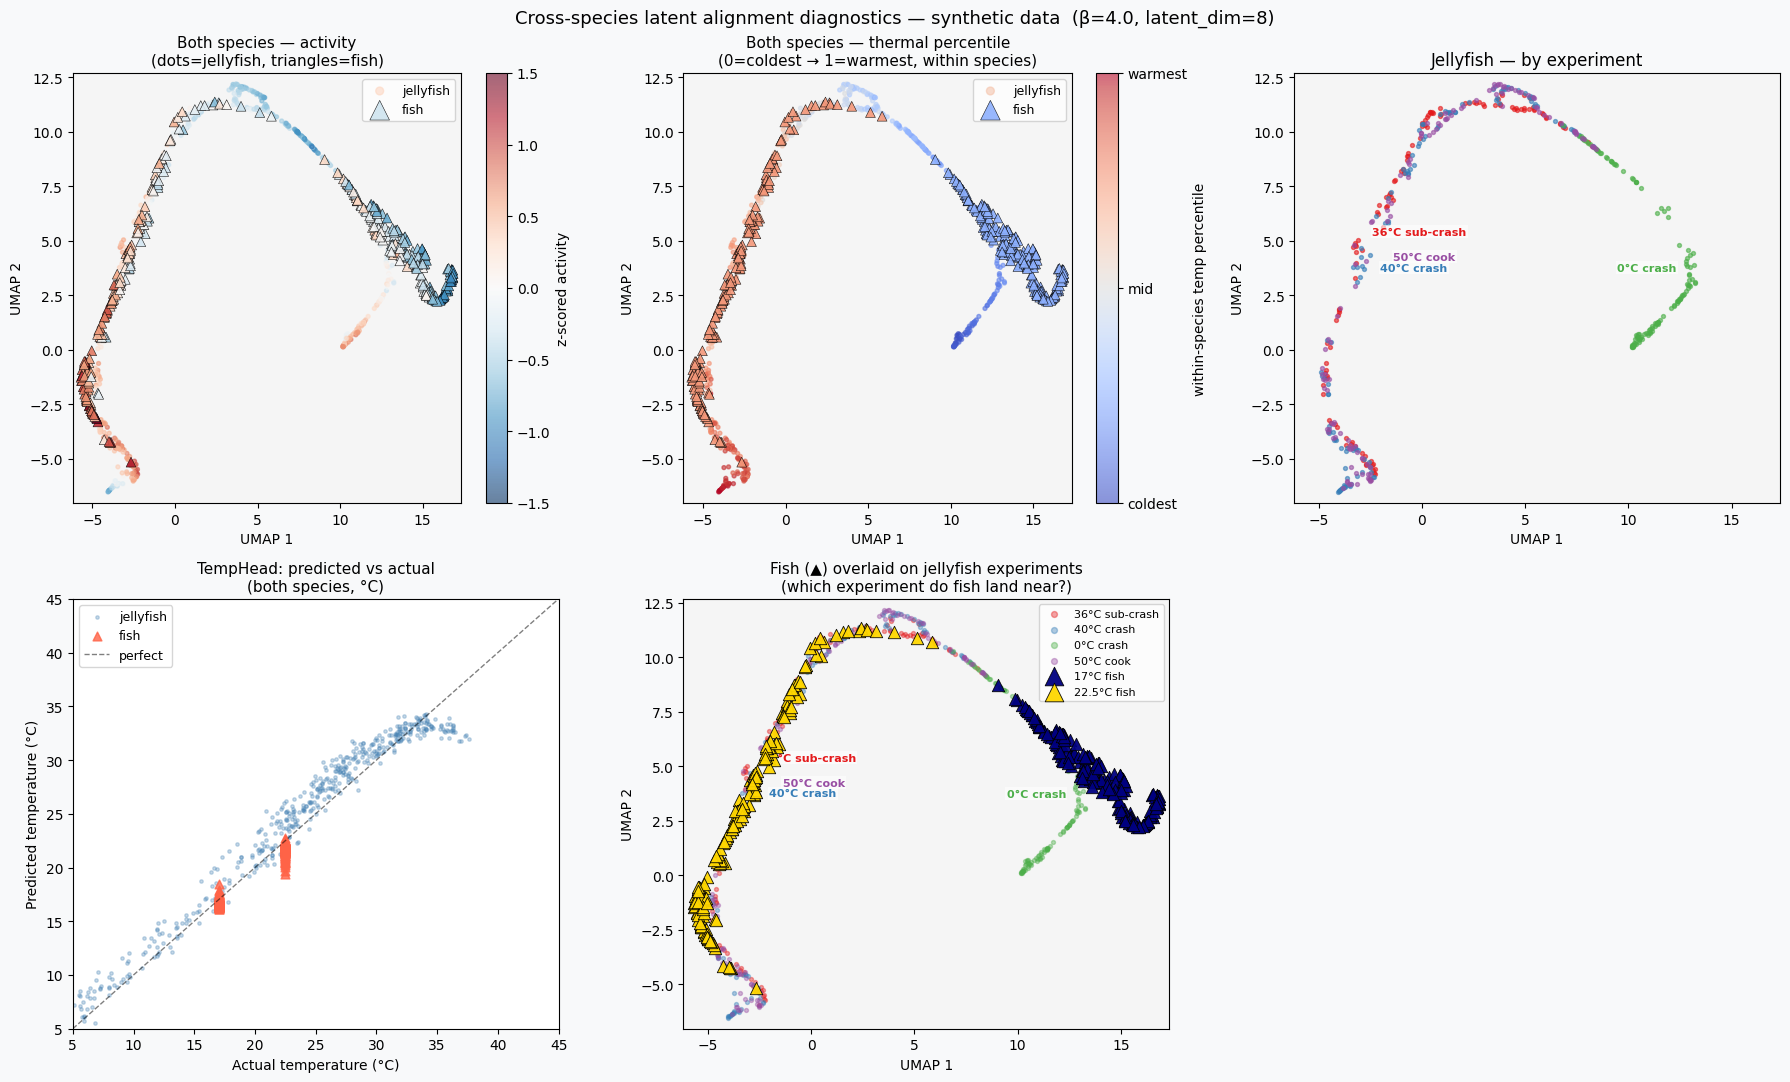

Saved → demo_latent_diagnostics.png


In [9]:
import umap
from scipy.stats import percentileofscore

model.eval()
mu_j, tp_j = encode_all(model, jelly_z[:, :, 0], 'jellyfish', device=DEVICE)
mu_f, tp_f = encode_all(model, fish_z[:,  :, 0], 'fish',      device=DEVICE)
mu_all     = np.vstack([mu_j, mu_f])

print('Fitting UMAP …')
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.15)
emb     = reducer.fit_transform(mu_all)
print('Done.')

emb_j = emb[:len(mu_j)]
emb_f = emb[len(mu_j):]

pad  = 0.5
xlim = (emb[:,0].min() - pad, emb[:,0].max() + pad)
ylim = (emb[:,1].min() - pad, emb[:,1].max() + pad)

act_j = jelly_z[:, :, 0].mean(axis=1)
act_f = fish_z[:,  :, 0].mean(axis=1)
act_vmin, act_vmax = -1.5, 1.5

def temp_pctile(temps):
    return np.array([percentileofscore(temps, t, kind='rank') / 100 for t in temps])

pctile_j = temp_pctile(jelly_temps)
pctile_f = temp_pctile(fish_temps)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
axes[5].set_visible(False)  # hide unused 6th panel
fig.patch.set_facecolor('#f8f9fa')

# ── 1. Both species — z-scored activity ───────────────────────────────────────
ax = axes[0]; ax.set_facecolor('#f5f5f5')
sc = ax.scatter(emb_j[:,0], emb_j[:,1], c=act_j, cmap='RdBu_r',
                vmin=act_vmin, vmax=act_vmax, s=8, alpha=0.6, marker='o', label='jellyfish')
ax.scatter(emb_f[:,0], emb_f[:,1], c=act_f, cmap='RdBu_r',
           vmin=act_vmin, vmax=act_vmax, s=50, alpha=0.9,
           marker='^', edgecolors='k', linewidths=0.4, label='fish')
plt.colorbar(sc, ax=ax, label='z-scored activity')
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.legend(markerscale=2, fontsize=9)
ax.set_title('Both species — activity\n(dots=jellyfish, triangles=fish)', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── 2. Both species — within-species thermal percentile ───────────────────────
ax = axes[1]; ax.set_facecolor('#f5f5f5')
sc2 = ax.scatter(emb_j[:,0], emb_j[:,1], c=pctile_j, cmap='coolwarm',
                 vmin=0, vmax=1, s=8, alpha=0.6, marker='o', label='jellyfish')
ax.scatter(emb_f[:,0], emb_f[:,1], c=pctile_f, cmap='coolwarm',
           vmin=0, vmax=1, s=50, alpha=0.9,
           marker='^', edgecolors='k', linewidths=0.4, label='fish')
cb = plt.colorbar(sc2, ax=ax, label='within-species temp percentile')
cb.set_ticks([0, 0.5, 1]); cb.set_ticklabels(['coldest', 'mid', 'warmest'])
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.legend(markerscale=2, fontsize=9)
ax.set_title('Both species — thermal percentile\n(0=coldest → 1=warmest, within species)', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── 3. Jellyfish — by experiment ──────────────────────────────────────────────
ax = axes[2]; ax.set_facecolor('#f5f5f5')
exp_colors   = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
short_labels = ['36°C sub-crash', '40°C crash', '0°C crash', '50°C cook']
jl_arr = np.array(jelly_labels)
for ei, exp in enumerate(EXPERIMENTS):
    m   = jl_arr == exp['label']
    pts = emb_j[m]
    ax.scatter(pts[:,0], pts[:,1], color=exp_colors[ei], s=8, alpha=0.6,
               label=short_labels[ei])
    cx, cy = pts[:,0].mean(), pts[:,1].mean()
    ax.text(cx, cy, short_labels[ei], fontsize=8, color=exp_colors[ei],
            ha='center', va='center', fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Jellyfish — by experiment', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── 4. Predicted vs actual temperature ────────────────────────────────────────
ax = axes[3]
tp_j_c = tp_j * j_temp_std + j_temp_mean
tp_f_c = tp_f * f_temp_std + f_temp_mean
valid_j = ~np.isnan(jelly_temps)
ax.scatter(jelly_temps[valid_j], tp_j_c[valid_j],
           c='steelblue', s=6, alpha=0.3, label='jellyfish')
ax.scatter(fish_temps, tp_f_c,
           c='tomato', s=40, marker='^', alpha=0.8, label='fish')
lim = [5, 45]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.5, label='perfect')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual temperature (°C)')
ax.set_ylabel('Predicted temperature (°C)')
ax.set_title('TempHead: predicted vs actual\n(both species, °C)', fontsize=11)
ax.legend(fontsize=9)

# ── 5. Fish overlaid on jellyfish experiments ──────────────────────────────────
ax = axes[4]; ax.set_facecolor('#f5f5f5')
for ei, exp in enumerate(EXPERIMENTS):
    m   = jl_arr == exp['label']
    pts = emb_j[m]
    ax.scatter(pts[:,0], pts[:,1], color=exp_colors[ei], s=8, alpha=0.4,
               label=short_labels[ei])
    cx, cy = pts[:,0].mean(), pts[:,1].mean()
    ax.text(cx, cy, short_labels[ei], fontsize=8, color=exp_colors[ei],
            ha='center', va='center', fontweight='bold',
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))
fish_groups = {17.0: ('navy', '17°C fish'), 22.5: ('gold', '22.5°C fish')}
for temp_val, (col, lbl) in fish_groups.items():
    m = np.isclose(fish_temps, temp_val)
    ax.scatter(emb_f[m,0], emb_f[m,1], color=col, s=80, alpha=0.95,
               marker='^', edgecolors='k', linewidths=0.6, label=lbl, zorder=5)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Fish (▲) overlaid on jellyfish experiments\n(which experiment do fish land near?)', fontsize=11)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=8, markerscale=1.5)

fig.suptitle(f'Cross-species latent alignment diagnostics — synthetic data  (β={BETA}, latent_dim={LATENT_DIM})',
             fontsize=13)
plt.tight_layout()
plt.savefig('demo_latent_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → demo_latent_diagnostics.png')


## Summary

| | Detail |
|---|---|
| **Jellyfish** | Synthetic: 4 experiment types (sub-crash, crash, cooling, cook); activity ∝ temperature proximity |
| **Fish** | Synthetic: two temperature groups (17 °C / 22.5 °C) |
| **Encoder** | Species-specific Conv1d → AdaptiveAvgPool1d(4) → FC; works for any window length |
| **Latent space** | 8-D Gaussian; shared across species |
| **TempHead** | Shared MLP regression head; supervised signal to align species along temperature axis |
| **Loss** | β-ELBO (β=4.0, annealed) + λ_temp=2.0 temperature regression |

**Real data** is available in `datasets/jellyfish_stickleback/` (2,975 jellyfish windows + 1,854 fish windows). See `notebooks/model.ipynb` to train on real data, and `scripts/preprocess_data.py` to regenerate from raw `.mat`/`.h5` files.